In [60]:
from data_feed import DataFeed
from engine import BacktestEngine
from evaluator import Evaluator
from strategy import Strategy

import matplotlib.pyplot as plt
import pandas as pd
import random

In [75]:
class DataDividFeed:
    def __init__(self, data: pd.DataFrame):
        """
        Loads the dataset from a parquet file.
        Expects a DataFrame with timestamps as the index.
        Supported column formats:
        1) MultiIndex columns: (ticker, field), e.g. ('AAPL', 'close'), ('AAPL', 'volume')
        2) Single-level columns: ticker only (treated as close-only data)
        """
        self.data = data
            
        if not isinstance(self.data.index, pd.DatetimeIndex):
            raise ValueError("The index of the dataset must be a DatetimeIndex.")

        if isinstance(self.data.columns, pd.MultiIndex):
            fields = self.data.columns.get_level_values(-1)
            if "close" not in fields:
                raise ValueError("MultiIndex dataset must include a 'close' field.")
            
        if self.data.isna().any().any():
            raise ValueError("Dataset contains NaN values. Please clean the data before backtesting.")

    def __iter__(self):
        """
        Allows the engine to iterate over the data row-by-row.
        Yields a tuple of (timestamp, pd.DataFrame of market data).
        Output DataFrame format at each timestamp:
        - Index: ticker
        - Columns: fields (e.g. close, volume)
        """
        for timestamp, row in self.data.iterrows():
            if isinstance(self.data.columns, pd.MultiIndex):
                # row index: MultiIndex (ticker, field) -> reshape to DataFrame
                current_market_data = row.unstack(level=-1)
            else:
                # Backward compatibility for close-only datasets
                current_market_data = pd.DataFrame({"close": row})

            yield timestamp, current_market_data

def strategy_performance_stat(df):

    df = df.apply(lambda x: pd.to_numeric(x.astype(str).str.replace('%', ''), errors='coerce'))
    df.loc[:, df.columns != 'Sharpe Ratio'] = df.loc[:, df.columns != 'Sharpe Ratio'] / 100

    stat_df = pd.DataFrame([
        df.mean(),
        df.std(),
        df.min(),
        df.quantile(0.25),
        df.median(),
        df.quantile(0.75),
        df.max()
    ], 
    index=['Mean', 'Std', 'min', 'Q1', 'Median', 'Q3', 'Max']).apply(lambda col: col.map(lambda x: f"{x:.2f}" if pd.notna(x) else "NaN"))

    return stat_df


def cum_returns_figure(cumulative_returns):
     plt.figure(figsize=(14, 6))

     # 按天分段画，统一蓝色，隔夜自动断开
     for d in cumulative_returns.index.normalize().unique():
          day = cumulative_returns[cumulative_returns.index.date == d.date()]
          plt.plot(day.index, day.values, color='blue')

     # 0线和网格
     plt.axhline(0, color='red', linestyle='--', alpha=0.7)
     plt.grid(alpha=0.3)
     plt.title('Cumulative Return (5min)')
     plt.xticks(rotation=30)
     plt.tight_layout()
     plt.show()

def run_strategy(feed):
    try:
        # 2. Initialize components
        print("Loading data...")
        
        print("Initializing strategy...")
        strategy = Strategy()
        
        engine = BacktestEngine(data_feed=feed, strategy=strategy)
        
        # 3. Run the backtest
        portfolio_returns = engine.run()
        
        # 4. Evaluate the results
        evaluator = Evaluator(portfolio_returns, periods_per_year=252*78)
        metrics = evaluator.generate_report()
        
        cumulative_returns = (1 + evaluator.returns).cumprod() - 1.0
        cum_returns_figure(cumulative_returns)

    except Exception as e:
        print(f"\n[BACKTEST FAILED] {type(e).__name__}: {e}")
        print("Please fix the error in your strategy and try again.")

    return metrics

def split_by_datetime_groups(df, group_weeks=2):
    if df.empty:
        return []
    
    # 2W-MON = 每 2 周，周一为起始（最常用！）
    grouper = df.groupby(pd.Grouper(freq=f"{group_weeks}W-SUN"))
    groups = [group for _, group in grouper if not group.empty]
    
    return groups

In [62]:
test_num = 2 # 测试集编号
train_path = "mini2/train.parquet" # 训练集路径
sample_times = 20 # 训练集抽样次数

--- Test 1 on Group 7 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 702/702 [00:01<00:00, 386.59step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -10.41%
Annualized Return        : -95.41%
Annualized Volatility    : 12.72%
Sharpe Ratio             : -7.50
Max Drawdown             : -10.41%
-----------------------------------


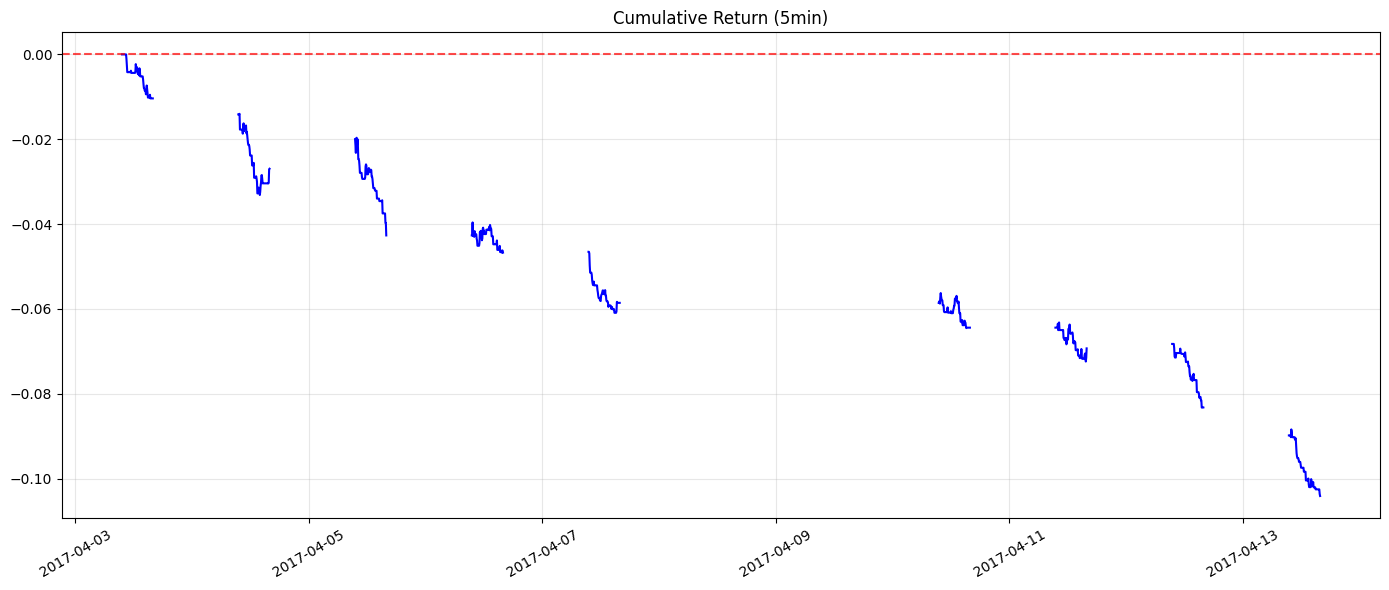

--- Test 2 on Group 12 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 409.32step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -12.13%
Annualized Return        : -96.17%
Annualized Volatility    : 17.52%
Sharpe Ratio             : -5.49
Max Drawdown             : -12.13%
-----------------------------------


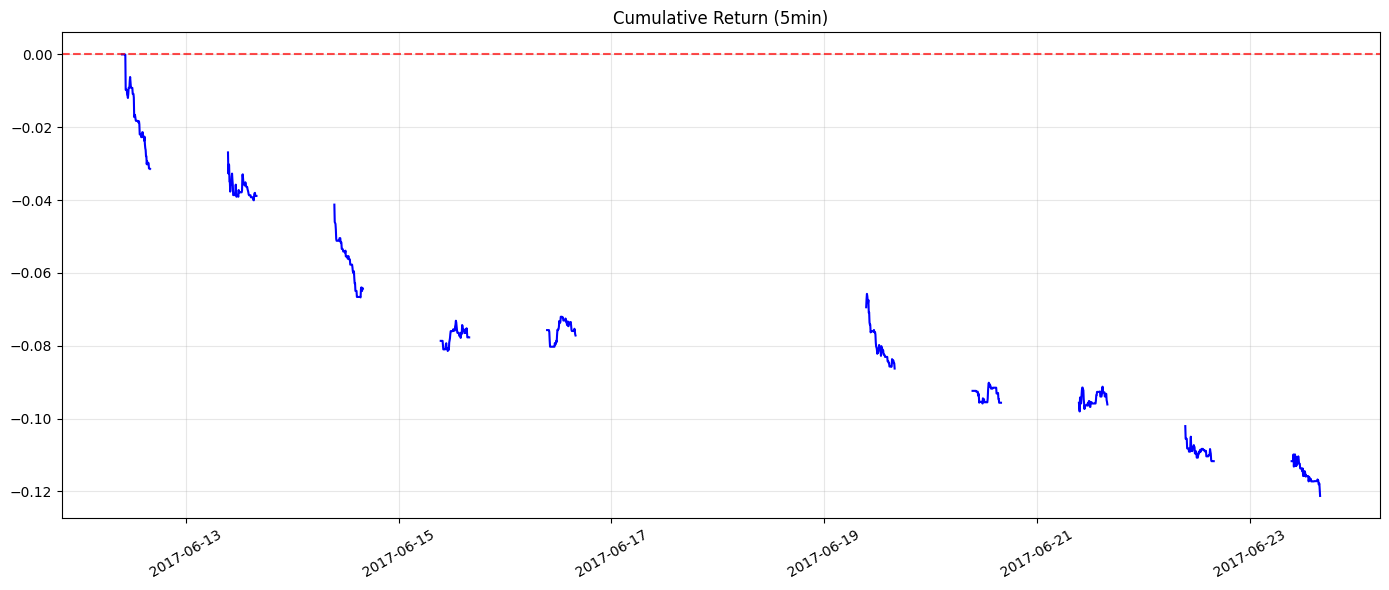

--- Test 3 on Group 18 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 702/702 [00:01<00:00, 379.67step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -8.25%
Annualized Return        : -91.06%
Annualized Volatility    : 13.89%
Sharpe Ratio             : -6.56
Max Drawdown             : -9.01%
-----------------------------------


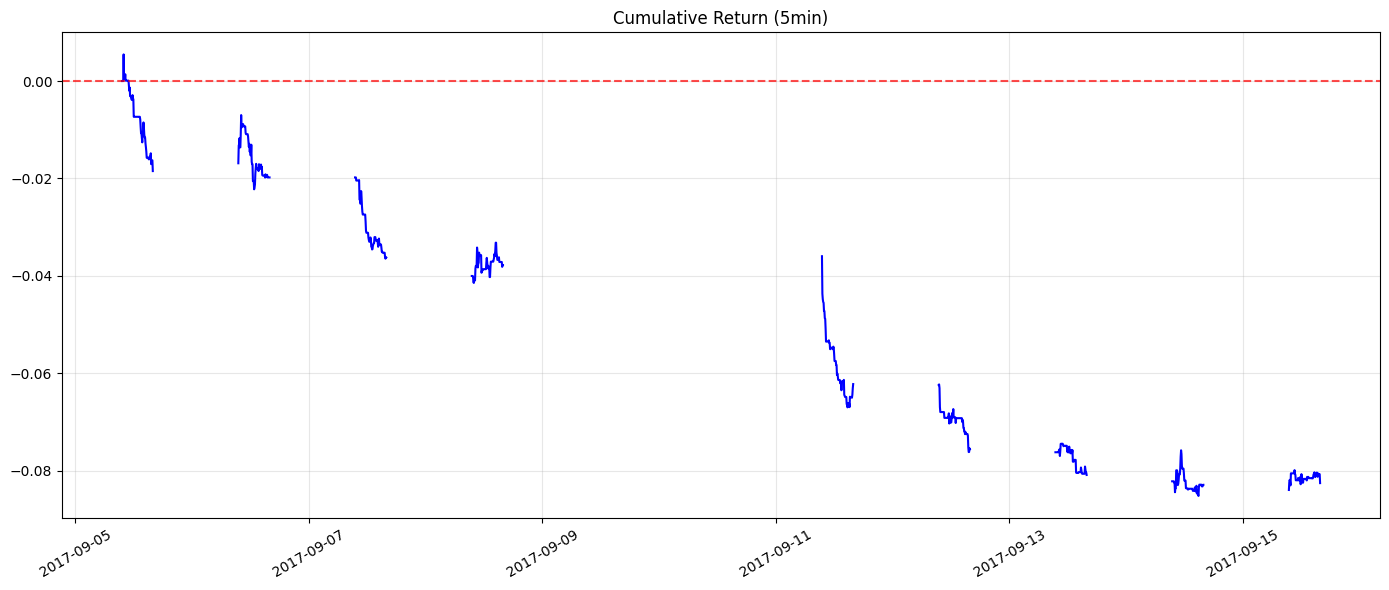

--- Test 4 on Group 20 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:02<00:00, 377.28step/s]

Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -11.84%
Annualized Return        : -95.84%
Annualized Volatility    : 12.91%
Sharpe Ratio             : -7.43
Max Drawdown             : -13.05%
-----------------------------------


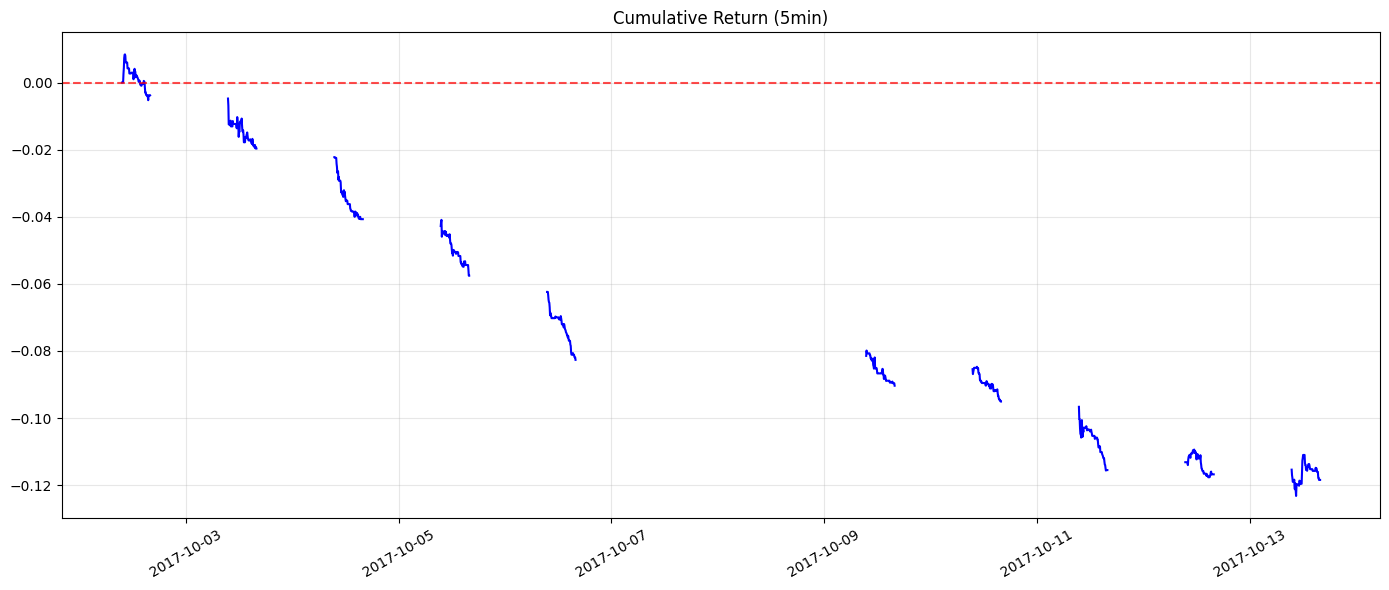

--- Test 5 on Group 26 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 624/624 [00:01<00:00, 413.96step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -8.33%
Annualized Return        : -93.56%
Annualized Volatility    : 11.96%
Sharpe Ratio             : -7.82
Max Drawdown             : -8.94%
-----------------------------------


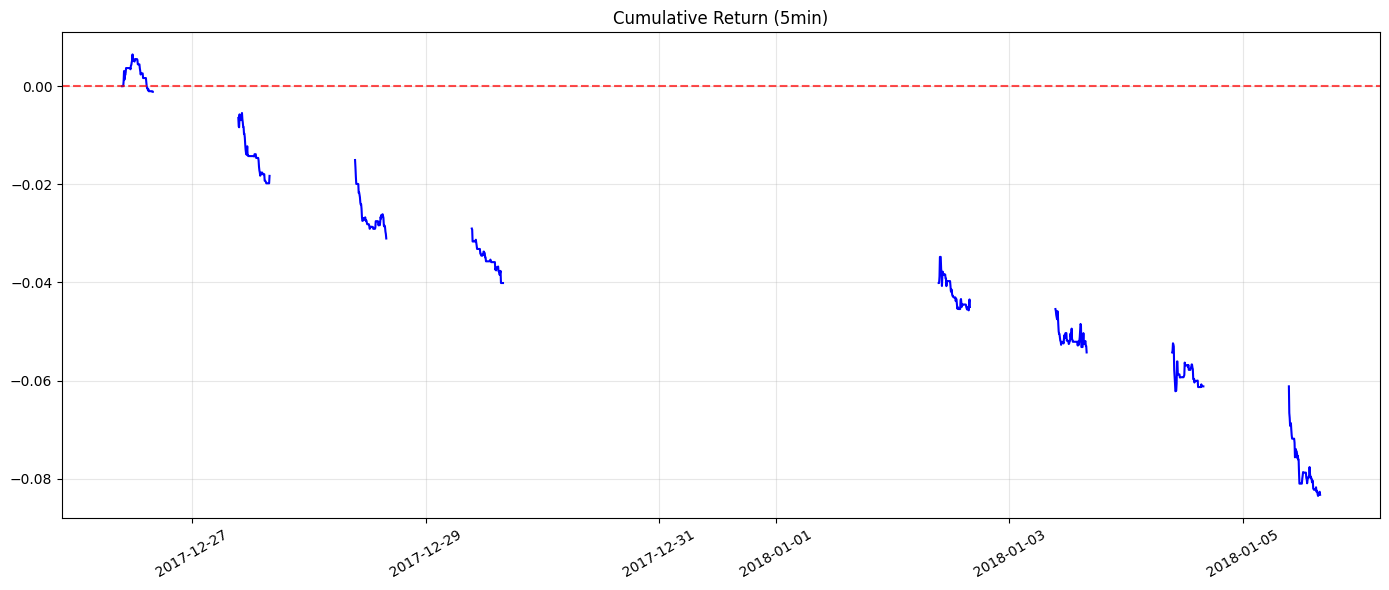

--- Test 6 on Group 52 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 590/590 [00:01<00:00, 364.43step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -6.84%
Annualized Return        : -90.59%
Annualized Volatility    : 20.89%
Sharpe Ratio             : -4.34
Max Drawdown             : -8.23%
-----------------------------------


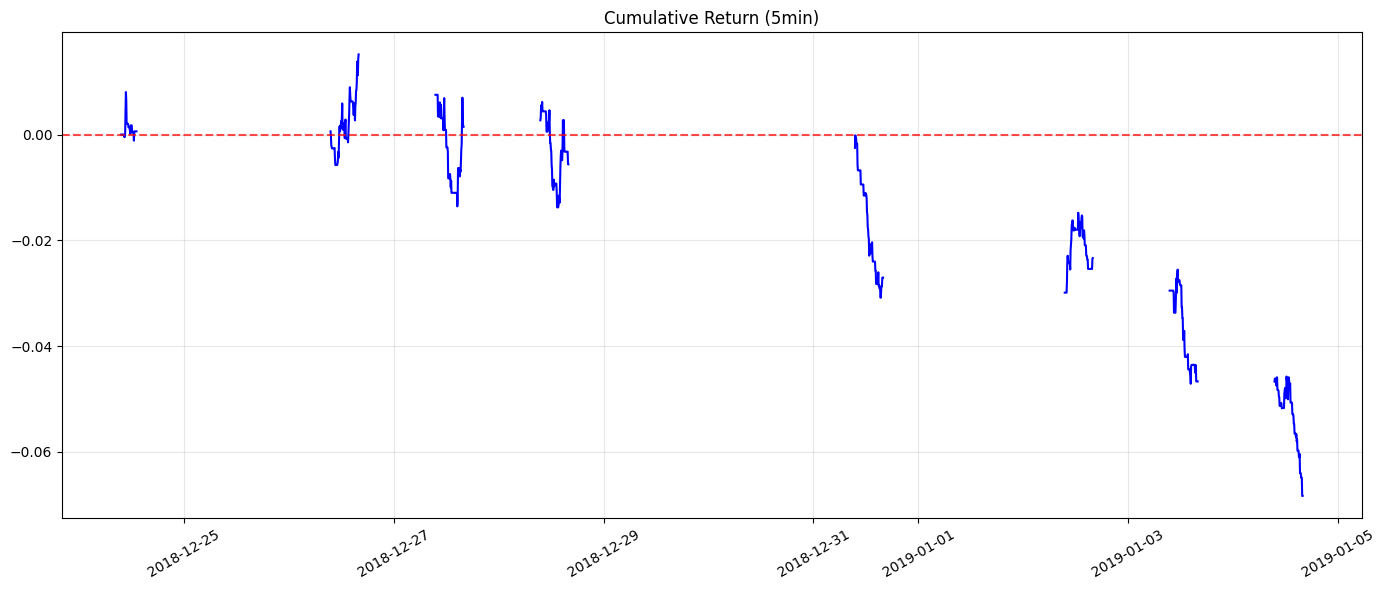

--- Test 7 on Group 63 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 702/702 [00:02<00:00, 337.36step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -2.92%
Annualized Return        : -56.46%
Annualized Volatility    : 18.89%
Sharpe Ratio             : -2.99
Max Drawdown             : -3.91%
-----------------------------------


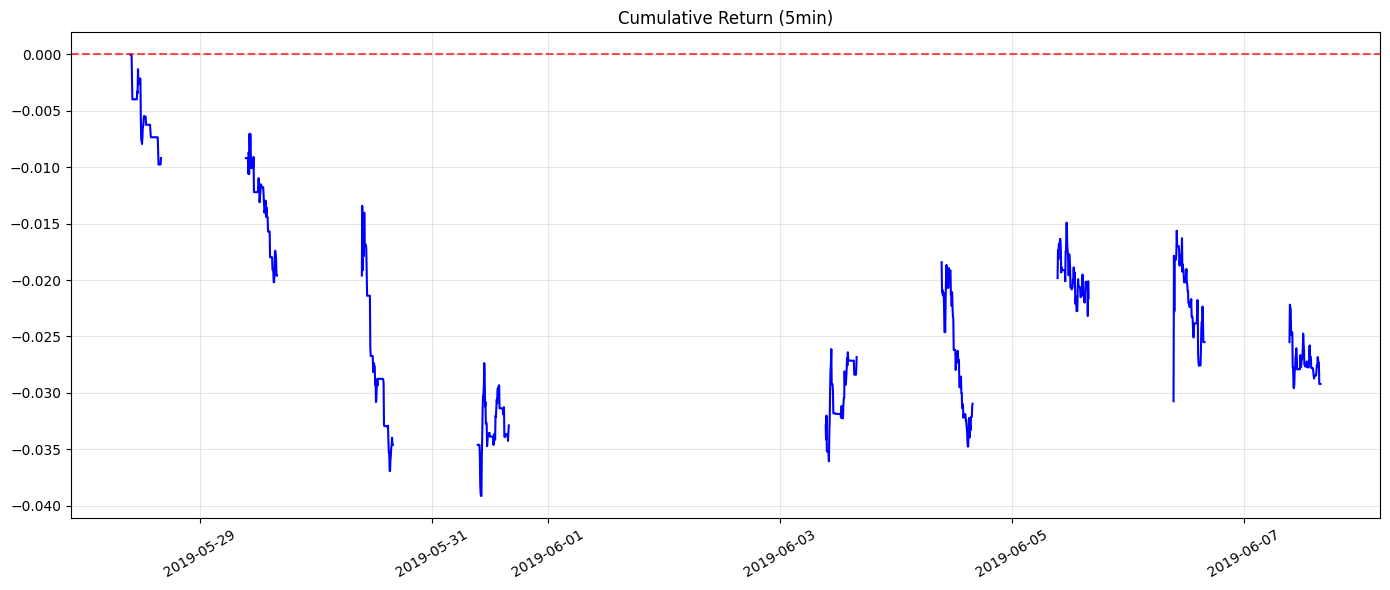

--- Test 8 on Group 79 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:02<00:00, 385.26step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -5.66%
Annualized Return        : -77.02%
Annualized Volatility    : 13.44%
Sharpe Ratio             : -5.73
Max Drawdown             : -6.02%
-----------------------------------


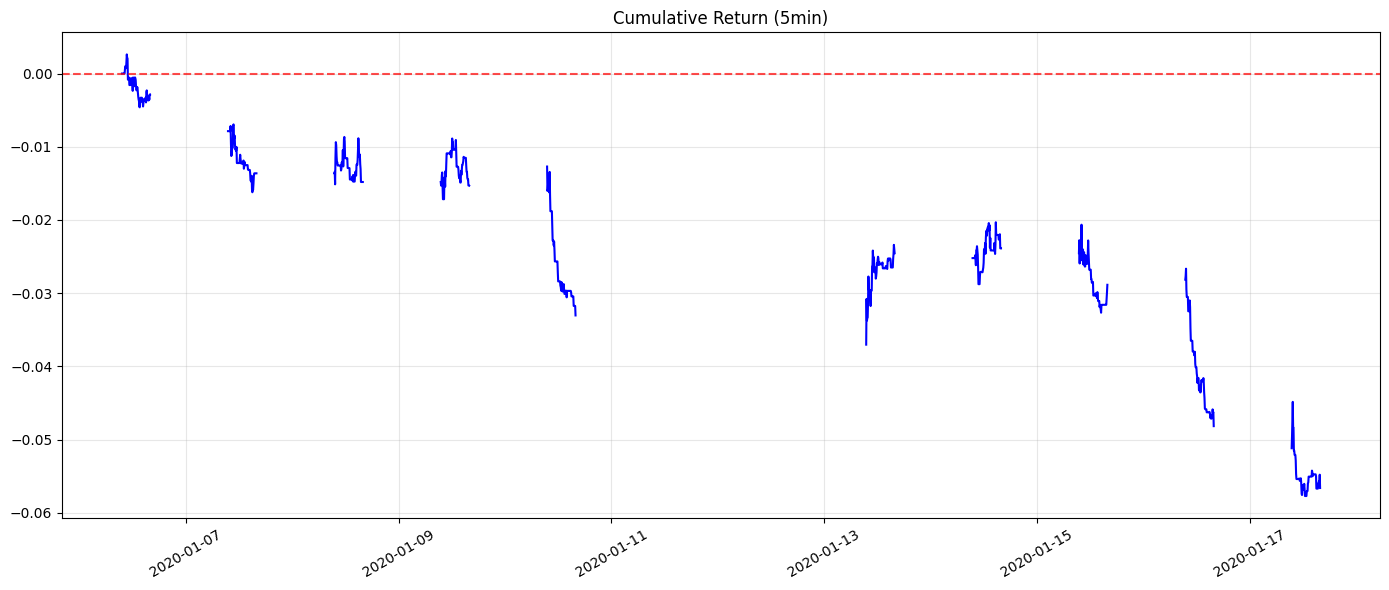

--- Test 9 on Group 86 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:02<00:00, 389.37step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -20.70%
Annualized Return        : -99.71%
Annualized Volatility    : 34.99%
Sharpe Ratio             : -2.85
Max Drawdown             : -22.27%
-----------------------------------


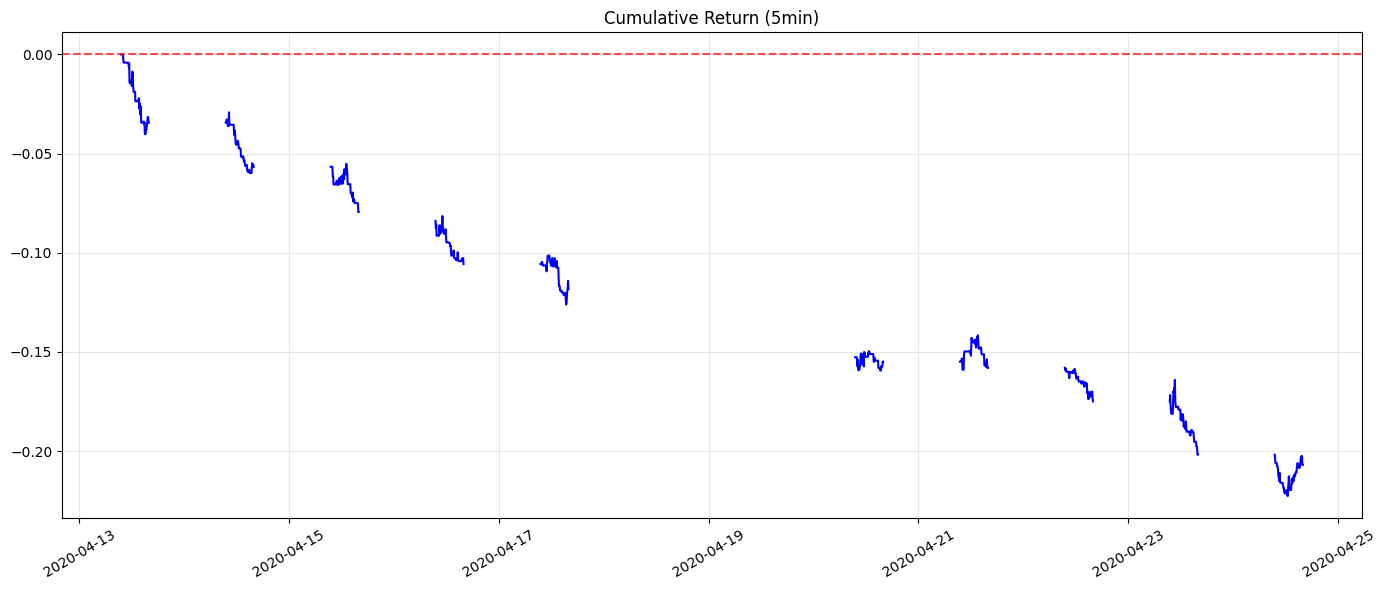

--- Test 10 on Group 107 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 395.06step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -3.45%
Annualized Return        : -58.78%
Annualized Volatility    : 20.15%
Sharpe Ratio             : -2.92
Max Drawdown             : -7.65%
-----------------------------------


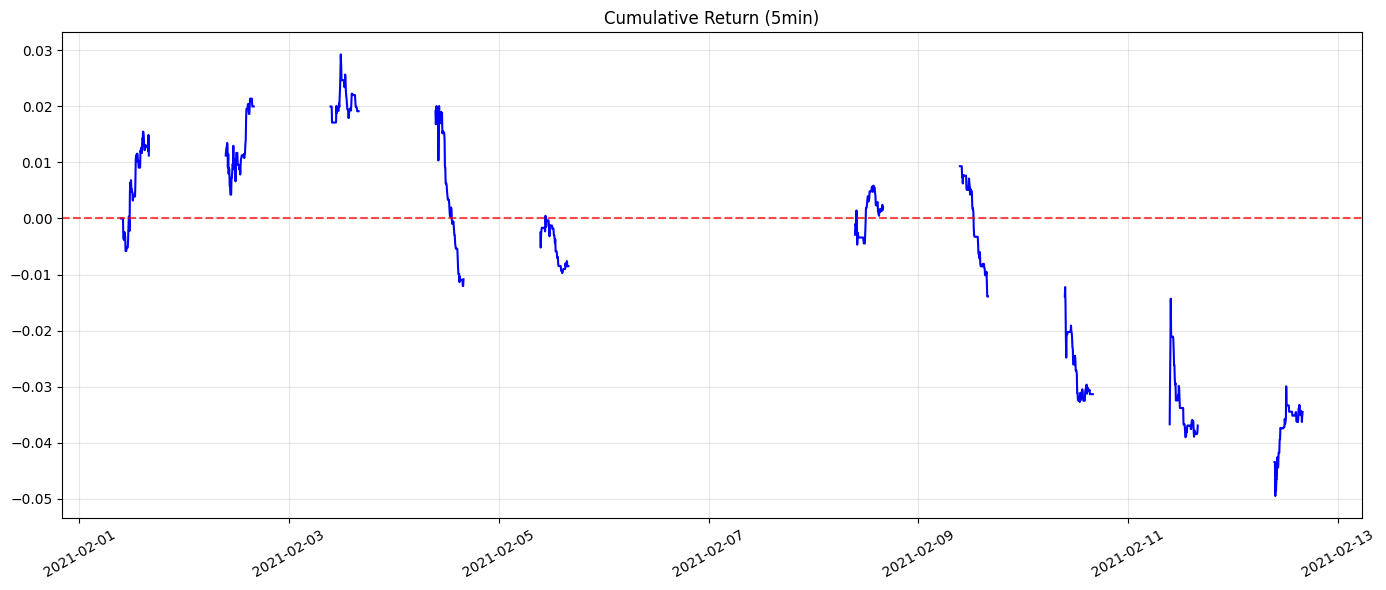

--- Test 11 on Group 122 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 702/702 [00:01<00:00, 396.05step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -6.58%
Annualized Return        : -85.16%
Annualized Volatility    : 13.07%
Sharpe Ratio             : -6.52
Max Drawdown             : -8.24%
-----------------------------------


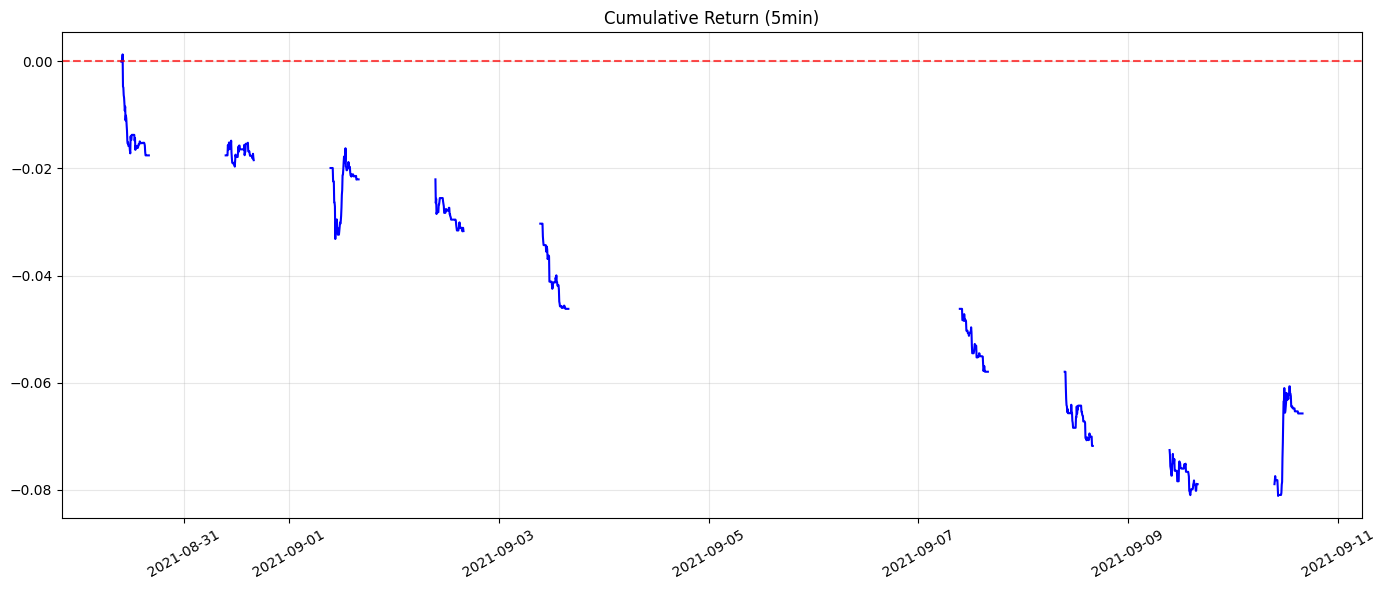

--- Test 12 on Group 125 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 401.16step/s]

Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : 2.17%
Annualized Return        : 71.99%
Annualized Volatility    : 17.71%
Sharpe Ratio             : 4.06
Max Drawdown             : -2.17%
-----------------------------------


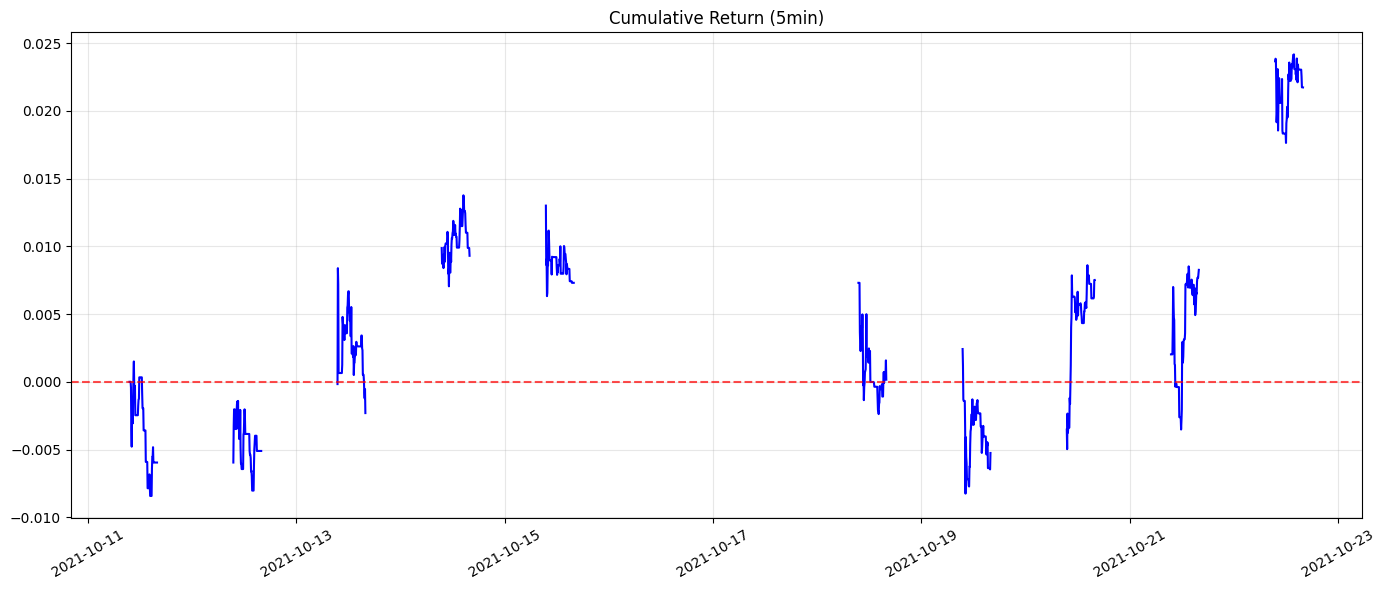

--- Test 13 on Group 138 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 702/702 [00:01<00:00, 404.27step/s]

Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -8.49%
Annualized Return        : -91.70%
Annualized Volatility    : 19.75%
Sharpe Ratio             : -4.64
Max Drawdown             : -9.29%
-----------------------------------


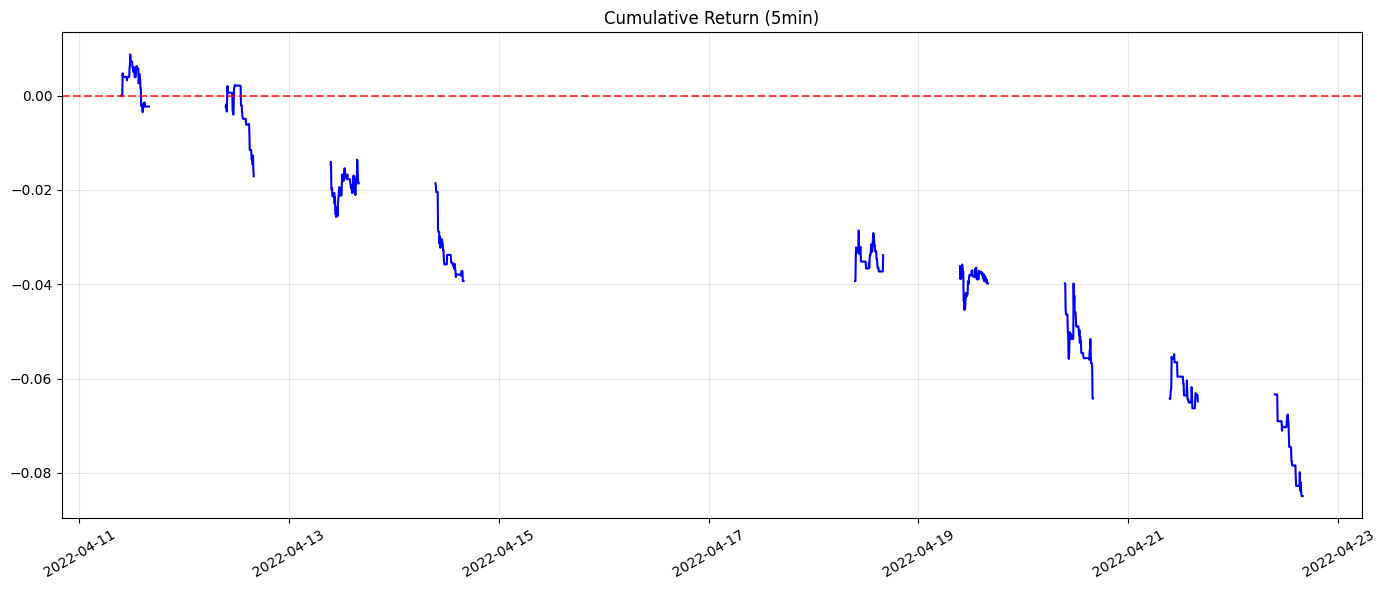

--- Test 14 on Group 155 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 393.55step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -2.58%
Annualized Return        : -48.25%
Annualized Volatility    : 28.97%
Sharpe Ratio             : -1.67
Max Drawdown             : -5.99%
-----------------------------------


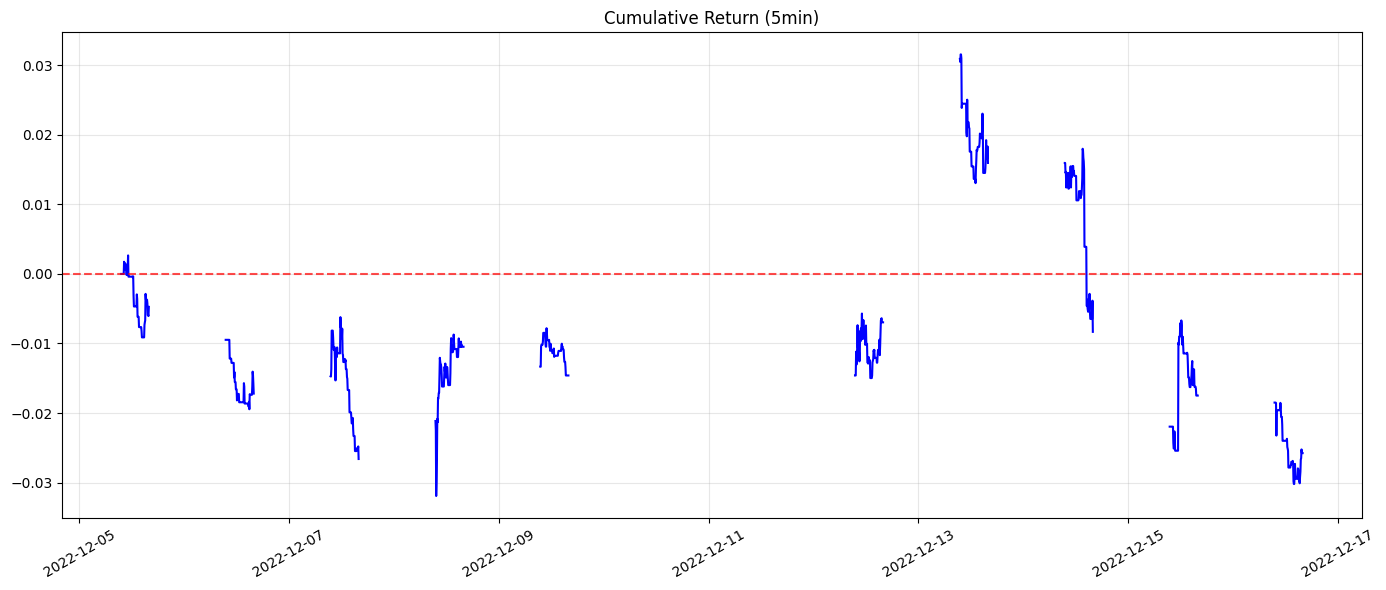

--- Test 15 on Group 156 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 702/702 [00:01<00:00, 399.48step/s]

Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -6.18%
Annualized Return        : -83.29%
Annualized Volatility    : 19.93%
Sharpe Ratio             : -4.18
Max Drawdown             : -7.31%
-----------------------------------


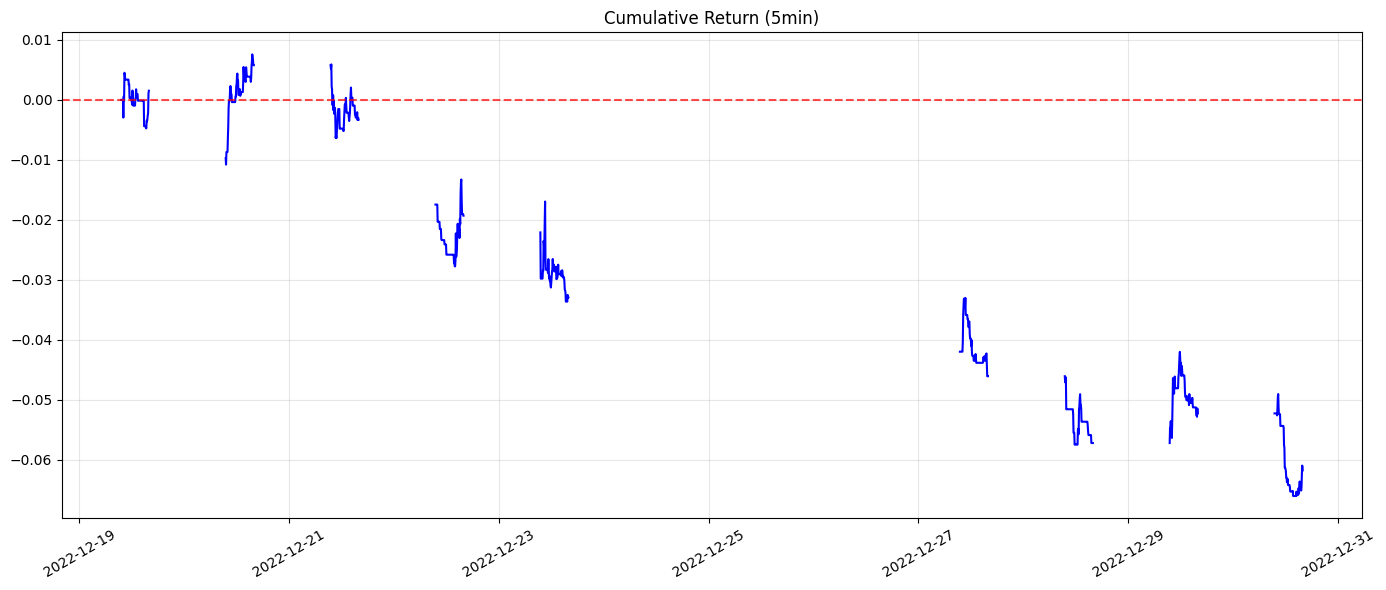

--- Test 16 on Group 165 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:02<00:00, 361.96step/s]

Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -3.68%
Annualized Return        : -61.19%
Annualized Volatility    : 19.32%
Sharpe Ratio             : -3.17
Max Drawdown             : -4.34%
-----------------------------------


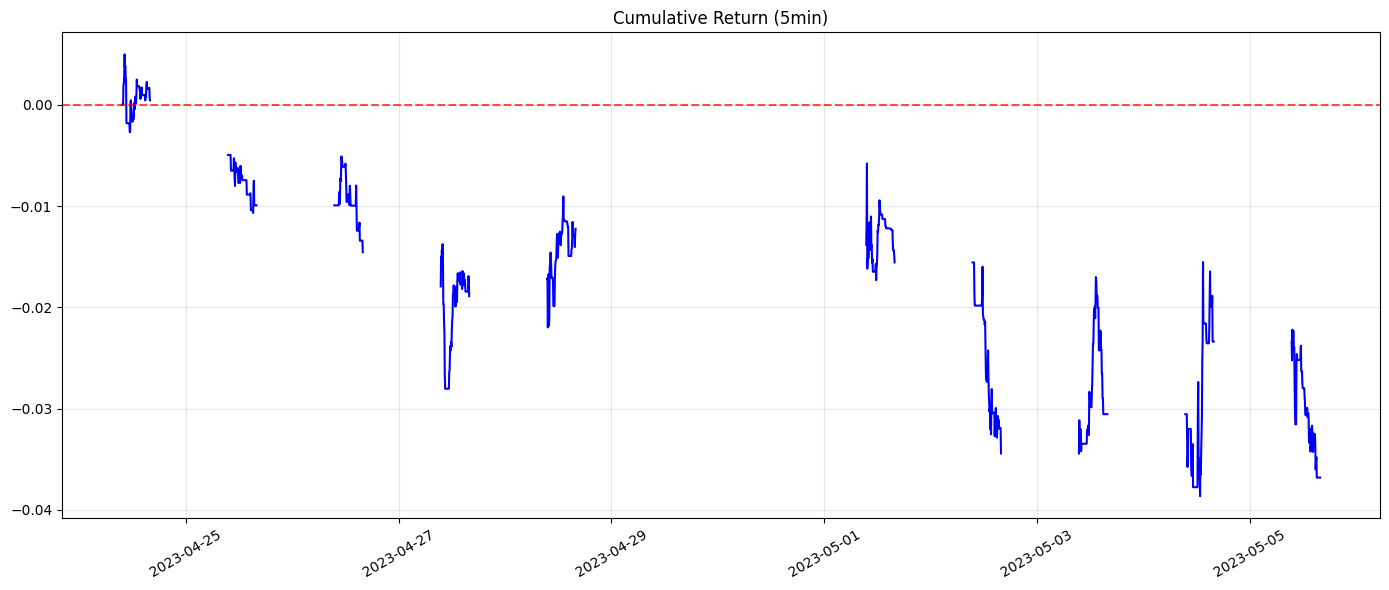

--- Test 17 on Group 187 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 398.22step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -3.81%
Annualized Return        : -62.49%
Annualized Volatility    : 18.80%
Sharpe Ratio             : -3.32
Max Drawdown             : -3.85%
-----------------------------------


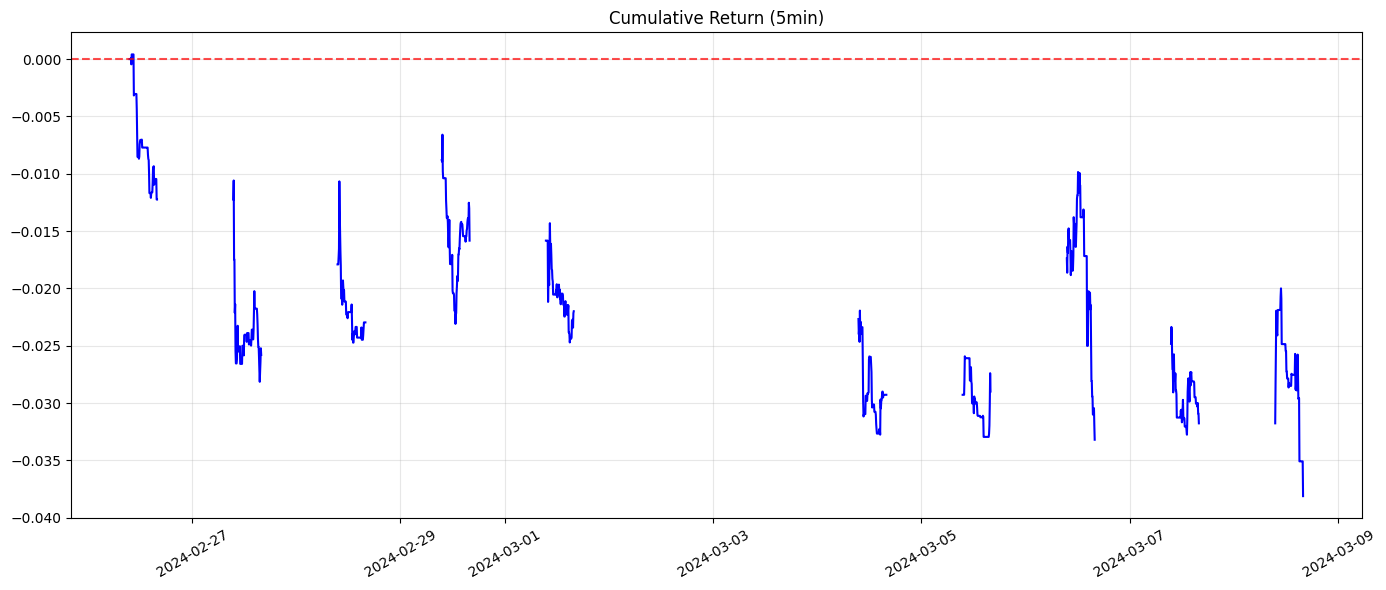

--- Test 18 on Group 198 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 396.58step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -17.89%
Annualized Return        : -99.31%
Annualized Volatility    : 34.06%
Sharpe Ratio             : -2.92
Max Drawdown             : -18.55%
-----------------------------------


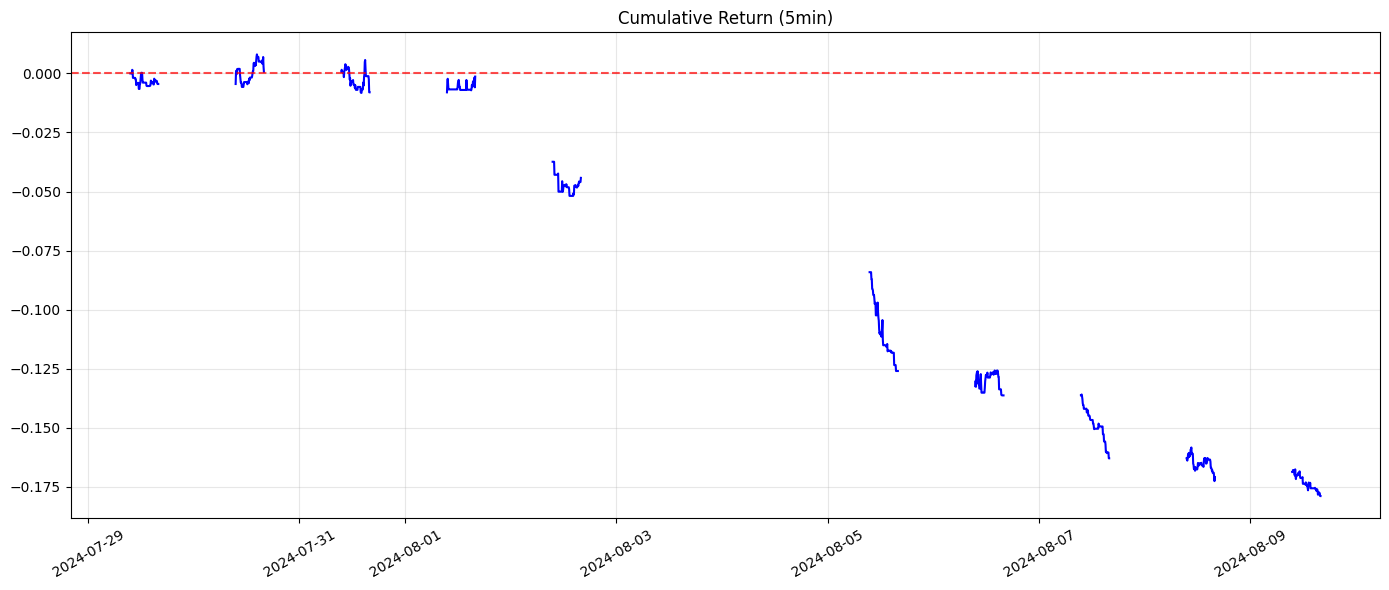

--- Test 19 on Group 202 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 399.73step/s]

Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -4.19%
Annualized Return        : -66.04%
Annualized Volatility    : 17.28%
Sharpe Ratio             : -3.82
Max Drawdown             : -5.24%
-----------------------------------


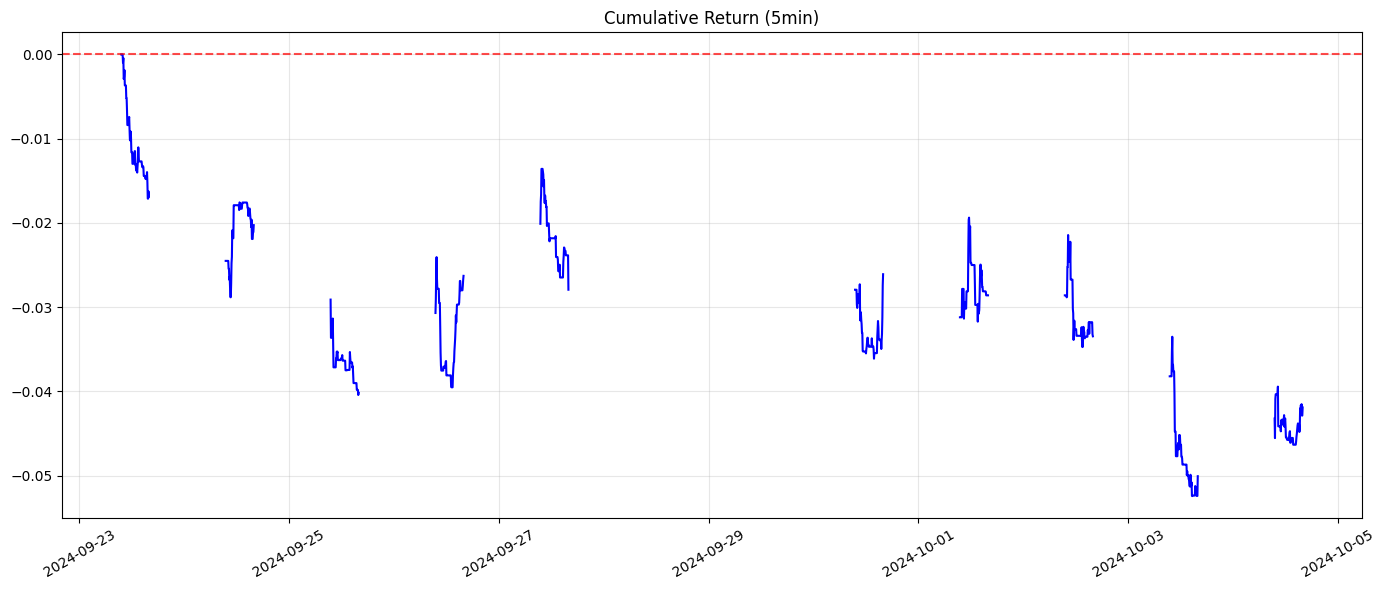

--- Test 20 on Group 207 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 395.84step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : -0.28%
Annualized Return        : -6.76%
Annualized Volatility    : 13.43%
Sharpe Ratio             : -0.50
Max Drawdown             : -2.75%
-----------------------------------


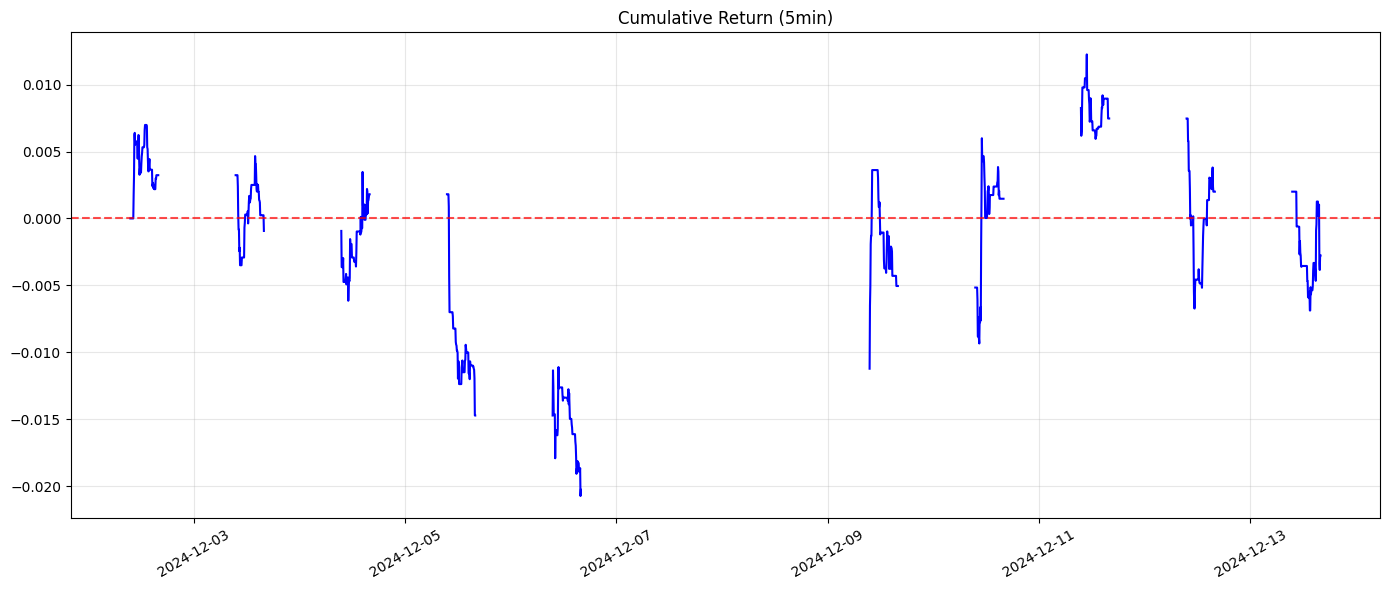

In [63]:
whole_data = pd.read_parquet(train_path)
groups = split_by_datetime_groups(whole_data)

samples = sorted(random.sample(range(len(groups)), sample_times))

j=0
all_group_metrics = []
for i in samples:
    j= j + 1 
    print(f"--- Test {j} on Group {i} ---\n")
    feed = DataDividFeed(groups[i])
    
    metrics = run_strategy(feed).copy()
    metrics["Group"] = f"Group {i}"
    all_group_metrics.append(metrics)

--- Test on testset 2 ---

Loading data...
Initializing strategy...
Starting backtest...


Backtest: 100%|██████████| 780/780 [00:01<00:00, 413.16step/s]


Backtest completed successfully.

--- Strategy Performance Report ---
Cumulative Return        : 1.79%
Annualized Return        : 56.38%
Annualized Volatility    : 17.37%
Sharpe Ratio             : 3.25
Max Drawdown             : -2.01%
-----------------------------------


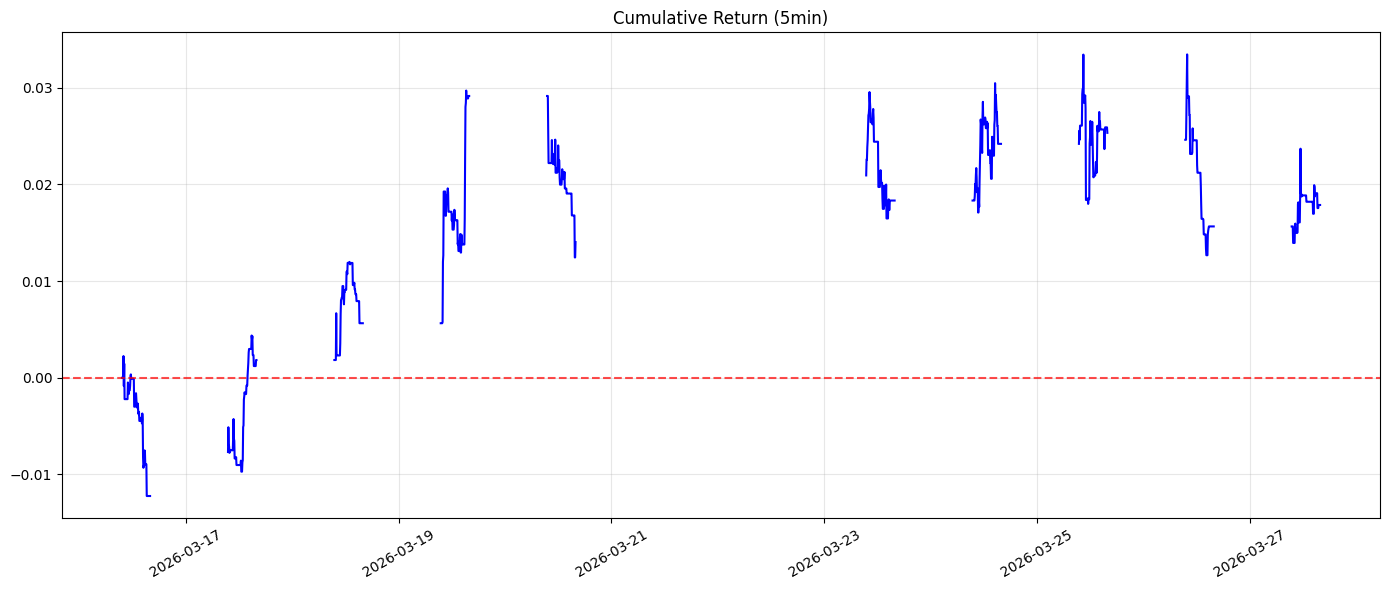

In [64]:
test_path = f"mini{test_num}/test.parquet"
print(f"--- Test on testset {test_num} ---\n")
feed = DataFeed(test_path)
    
metrics = run_strategy(feed)
metrics["Group"] = f"Test {test_num}"
all_group_metrics.append(metrics)

In [76]:
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

df = pd.DataFrame(all_group_metrics).set_index("Group")

#df_sorted = df.sort_values(by="Sharpe Ratio", ascending=False)

print("--- ALL GROUPS PERFORMANCE ---\n")
print(df)

stat_df = strategy_performance_stat(df)

print("--- STRATEGY PERFORMANCE ---\n")
print(stat_df)

--- ALL GROUPS PERFORMANCE ---

          Cumulative Return Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown
Group                                                                                        
Group 7             -10.41%           -95.41%                12.72%        -7.50      -10.41%
Group 12            -12.13%           -96.17%                17.52%        -5.49      -12.13%
Group 18             -8.25%           -91.06%                13.89%        -6.56       -9.01%
Group 20            -11.84%           -95.84%                12.91%        -7.43      -13.05%
Group 26             -8.33%           -93.56%                11.96%        -7.82       -8.94%
Group 52             -6.84%           -90.59%                20.89%        -4.34       -8.23%
Group 63             -2.92%           -56.46%                18.89%        -2.99       -3.91%
Group 79             -5.66%           -77.02%                13.44%        -5.73       -6.02%
Group 86            -20.70% 